In [1]:
import torch

if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [2]:
import torch
import torch.nn as nn
class SimpleMathCNN(nn.Module):
    def __init__(self, num_classes = 10):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride = 2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 7 * 7, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.fc(x)
        return x




In [3]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    val_metric = metric.clone()
    val_metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            val_metric.update(y_pred, y_batch)
    return val_metric.compute()

In [4]:
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = loss_fn(y_pred,y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history



In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.5,),  std = (0.5,))
])

dataset_path = 'D:/Projekty/kalkulator/model/data/dataset'
full_dataset = datasets.ImageFolder(root = dataset_path, transform=transform)

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
valid_size = total_size - train_size

generator = torch.Generator()
train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size],
    generator=generator
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(full_dataset.classes)
print(f"Liczba obrazków: {total_size} (Train: {train_size}, Valid: {valid_size})")
print(f"Liczba klas: {num_classes}")



Liczba obrazków: 10071 (Train: 8056, Valid: 2015)
Liczba klas: 19


In [6]:
from torch import optim as optim
import torchmetrics

num_classes = 19


metric = torchmetrics.F1Score(
    task="multiclass",
    num_classes=num_classes,
    average="macro"
).to(device)

model = SimpleMathCNN(num_classes=num_classes).to(device)

n_epochs = 40
loss_fn = nn.CrossEntropyLoss()
lr = 0.0001
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

In [7]:
history = train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs)

print(history)

Epoch 1/40, train loss: 2.1275, train metric: 0.3746, valid metric: 0.6077
Epoch 2/40, train loss: 1.3731, train metric: 0.6136, valid metric: 0.7188
Epoch 3/40, train loss: 1.0302, train metric: 0.7082, valid metric: 0.7786
Epoch 4/40, train loss: 0.8026, train metric: 0.7703, valid metric: 0.8290
Epoch 5/40, train loss: 0.6610, train metric: 0.8150, valid metric: 0.8378
Epoch 6/40, train loss: 0.5638, train metric: 0.8417, valid metric: 0.8744
Epoch 7/40, train loss: 0.4677, train metric: 0.8715, valid metric: 0.8840
Epoch 8/40, train loss: 0.4162, train metric: 0.8862, valid metric: 0.8853
Epoch 9/40, train loss: 0.3665, train metric: 0.8978, valid metric: 0.9044
Epoch 10/40, train loss: 0.3237, train metric: 0.9114, valid metric: 0.9099
Epoch 11/40, train loss: 0.2809, train metric: 0.9262, valid metric: 0.9159
Epoch 12/40, train loss: 0.2563, train metric: 0.9315, valid metric: 0.9238
Epoch 13/40, train loss: 0.2294, train metric: 0.9378, valid metric: 0.9250
Epoch 14/40, train lo

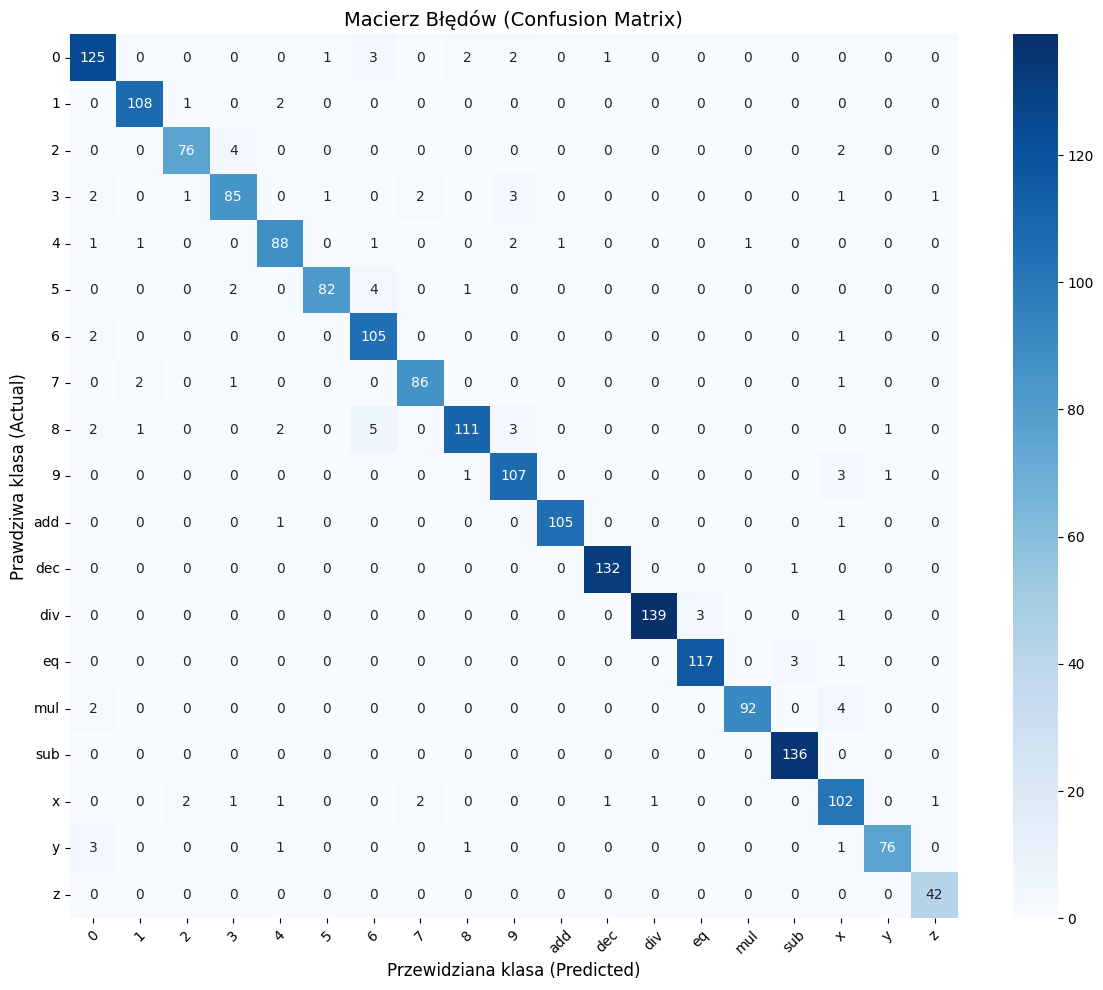

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
confmat = torchmetrics.ConfusionMatrix(
    task="multiclass",
    num_classes=num_classes
).to(device)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        X_batch = X_batch.to(device)

        y_pred = model(X_batch)
        preds = torch.argmax(y_pred, dim=1)

        all_preds.append(preds)
        all_targets.append(y_batch.to(device))

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

cm = confmat(all_preds, all_targets).cpu().numpy()

plt.figure(figsize=(12, 10))

class_names = full_dataset.classes

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Przewidziana klasa (Predicted)", fontsize=12)
plt.ylabel("Prawdziwa klasa (Actual)", fontsize=12)
plt.title("Macierz Błędów (Confusion Matrix)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [33]:
from PIL import Image

def predict_custom_image(image_path, model, transform, class_names):
    model.eval()
    img = Image.open(image_path)
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()

    return class_names[pred_idx]

my_symbol = predict_custom_image('test_plus.png', model, transform, full_dataset.classes)
print(f"Model twierdzi, że to symbol: {my_symbol}")

Model twierdzi, że to symbol: x


In [35]:
import json

mapping = full_dataset.class_to_idx

with open('class_mapping.json', 'w') as f:
    json.dump(mapping, f, indent=4)
